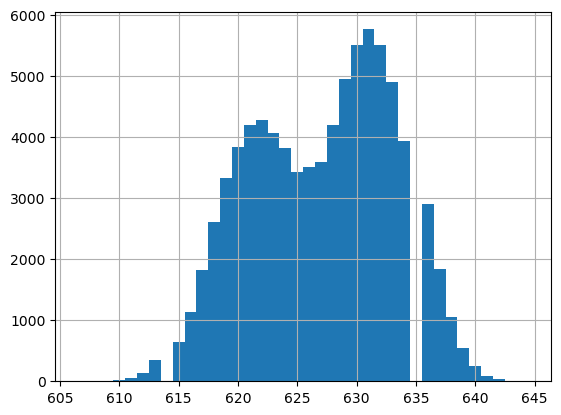

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("sensor_data_600.txt",delimiter=" ",
                   header=None, names=("date","time","ir","lidar"))

data["lidar"].hist(bins=max(data["lidar"])-min(data["lidar"]),align='left')
plt.show()

#sensor_data_600.txtからデータを読み込み、データのlidar列のヒストグラムを作成

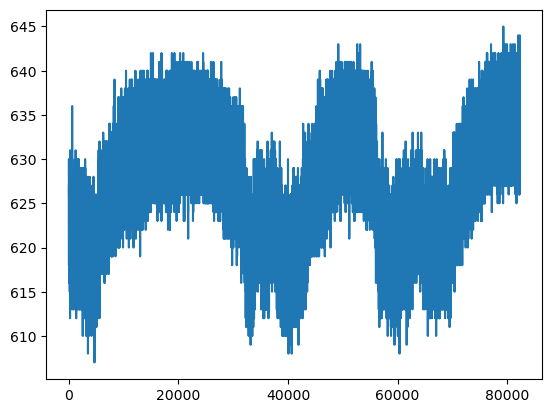

In [2]:
data.lidar.plot()      #data["lidar"].plotと同じ意味？　変数名によっては使えない
plt.show()             #今回のデータでは時系列順のセンサ値がグラフとして描画されている

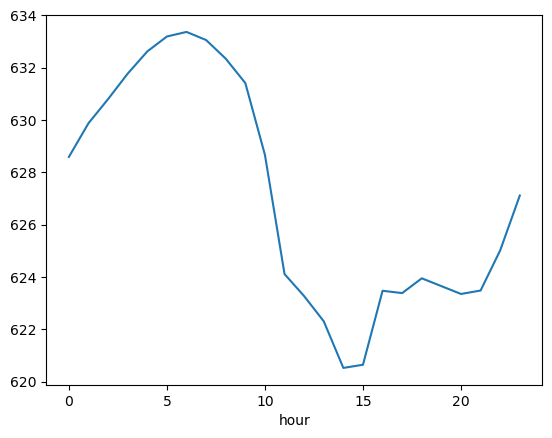

In [3]:
data["hour"]=[e//10000 for e in data.time]
#データフレームにhourという列を追加、hourには時分秒の６桁のデータを10000で割り、時間だけ残す
#//は小数点以下を切り捨てる割り算　　　　　　　　　　　　↑105320の場合、10となる
d = data.groupby("hour")
#hour列の値ごとに各レコードをグループ分けしたデータフレームdを作成  data("hour":"lidar")
d.lidar.mean().plot()        #dの時間ごとのlidarのセンサ値の平均値を求め、プロット
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

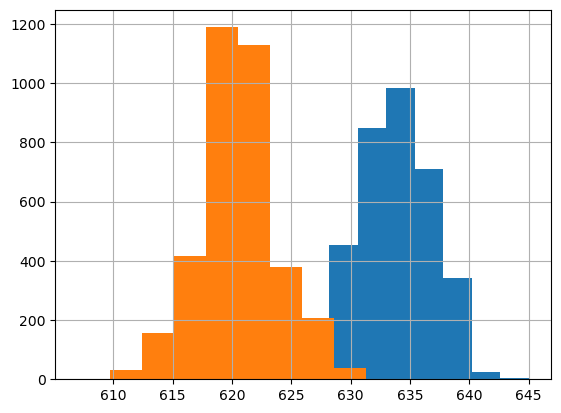

In [5]:
d.lidar.get_group(6).hist()      #dのレコード(6)にあるセンサ値のヒストグラム作成
d.lidar.get_group(14).hist()     #14時のセンサ値のヒストグラム
plt.show